# Instagram Reach Analysis


## Objective

Analyze Instagram post performance and identify the factors
that influence reach and engagement.

In [2]:
from itertools import groupby

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fontTools.diff import color

In [3]:
df=pd.read_csv('instagram_reach_analysis.csv')

In [4]:
df.head()

,Post_ID,Date,Post_Type,Caption_Length,Hashtags,Posting_Hour,Video_Duration_Sec,Likes,Comments,Shares,Saves,Followers,Reach,Impressions,Profile_Visits,Website_Clicks,New_Followers
0,1,2022-01-01,Reel,252.0,13.0,11,49,260.0,23.0,16.0,15.0,4000,5651,8864,87,11,22
1,2,2022-01-02,Reel,78.0,8.0,7,61,230.0,24.0,35.0,14.0,4010,6493,10142,100,16,25
2,3,2022-01-03,Story,171.0,10.0,20,14,155.0,7.0,9.0,21.0,4021,3534,4883,177,51,39
3,4,2022-01-04,Reel,157.0,16.0,15,35,568.0,57.0,54.0,NaN,4031,7334,12278,334,83,76
4,5,2022-01-05,Reel,22.0,20.0,18,29,325.0,22.0,57.0,24.0,4042,8213,9960,87,19,9


In [5]:
df.shape

(2010, 17)

In [6]:
df.columns

Index(['Post_ID', 'Date', 'Post_Type', 'Caption_Length', 'Hashtags',
       'Posting_Hour', 'Video_Duration_Sec', 'Likes', 'Comments', 'Shares',
       'Saves', 'Followers', 'Reach', 'Impressions', 'Profile_Visits',
       'Website_Clicks', 'New_Followers'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Post_ID             2010 non-null   int64  
 1   Date                2010 non-null   str    
 2   Post_Type           2010 non-null   str    
 3   Caption_Length      1998 non-null   float64
 4   Hashtags            2000 non-null   float64
 5   Posting_Hour        2010 non-null   int64  
 6   Video_Duration_Sec  2010 non-null   int64  
 7   Likes               1990 non-null   float64
 8   Comments            1994 non-null   float64
 9   Shares              1992 non-null   float64
 10  Saves               1996 non-null   float64
 11  Followers           2010 non-null   int64  
 12  Reach               2010 non-null   int64  
 13  Impressions         2010 non-null   int64  
 14  Profile_Visits      2010 non-null   int64  
 15  Website_Clicks      2010 non-null   int64  
 16  New_Followers    

In [8]:
df.describe()

,Post_ID,Caption_Length,Hashtags,Posting_Hour,Video_Duration_Sec,Likes,Comments,Shares,Saves,Followers,Reach,Impressions,Profile_Visits,Website_Clicks,New_Followers
count,2010.000000,1998.000000,2000.000000,2010.000000,2010.000000,1990.000000,1994.000000,1992.000000,1996.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000
mean,999.987065,156.349349,9.865000,14.524876,24.657214,876.722613,60.184554,138.346888,83.655311,14494.112935,13454.370647,19227.559701,466.602488,81.194030,100.320896
std,577.215760,82.780934,5.944194,5.200952,29.197827,651.382455,52.333113,120.565134,76.139480,6063.791551,8796.816350,12842.935713,376.675018,80.473445,94.836203
min,1.000000,10.000000,0.000000,6.000000,0.000000,10.000000,1.000000,1.000000,1.000000,4000.000000,300.000000,360.000000,3.000000,0.000000,0.000000
25%,501.250000,85.000000,5.000000,10.000000,0.000000,393.000000,24.000000,54.000000,31.000000,9254.750000,6512.250000,9188.250000,188.500000,27.000000,34.000000
50%,1000.500000,157.000000,10.000000,14.000000,10.000000,696.000000,45.000000,100.000000,61.000000,14499.500000,11429.500000,16291.500000,357.000000,55.000000,69.000000
75%,1498.750000,227.750000,15.000000,19.000000,48.000000,1203.750000,81.000000,188.250000,111.000000,19733.500000,18747.000000,26775.500000,636.750000,105.000000,132.000000
max,2000.000000,299.000000,20.000000,23.000000,90.000000,3918.000000,410.000000,972.000000,624.000000,25000.000000,46327.000000,71112.000000,2343.000000,660.000000,709.000000


#### **Check Missing Values**

In [9]:
df.isnull().sum()

Post_ID                0
Date                   0
Post_Type              0
Caption_Length        12
Hashtags              10
Posting_Hour           0
Video_Duration_Sec     0
Likes                 20
Comments              16
Shares                18
Saves                 14
Followers              0
Reach                  0
Impressions            0
Profile_Visits         0
Website_Clicks         0
New_Followers          0
dtype: int64

#### **Check Duplicate Rows**

In [10]:
df.duplicated().sum()

np.int64(10)

##### Remove duplicate rows ::

In [11]:
df=df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(2000, 17)

#### Handle Missing Values

In [14]:
df.isnull().sum()

Post_ID                0
Date                   0
Post_Type              0
Caption_Length        12
Hashtags              10
Posting_Hour           0
Video_Duration_Sec     0
Likes                 20
Comments              16
Shares                18
Saves                 14
Followers              0
Reach                  0
Impressions            0
Profile_Visits         0
Website_Clicks         0
New_Followers          0
dtype: int64

##### Fill missing values using median

In [15]:
df["Likes"] = df["Likes"].fillna(df["Likes"].median())

In [16]:
df["Caption_Length"] = df["Caption_Length"].fillna(df["Caption_Length"].median())

In [17]:
df["Hashtags"] = df["Hashtags"].fillna(df["Hashtags"].median())

In [18]:
df["Comments"] = df["Comments"].fillna(df["Comments"].median())

In [19]:
df["Saves"] = df["Saves"].fillna(df["Saves"].median())

In [20]:
df["Shares"] = df["Shares"].fillna(df["Shares"].median())

now,check missing values

In [21]:
df.isnull().sum()

Post_ID               0
Date                  0
Post_Type             0
Caption_Length        0
Hashtags              0
Posting_Hour          0
Video_Duration_Sec    0
Likes                 0
Comments              0
Shares                0
Saves                 0
Followers             0
Reach                 0
Impressions           0
Profile_Visits        0
Website_Clicks        0
New_Followers         0
dtype: int64

#### Check Datatypes

In [22]:
df.dtypes

Post_ID                 int64
Date                      str
Post_Type                 str
Caption_Length        float64
Hashtags              float64
Posting_Hour            int64
Video_Duration_Sec      int64
Likes                 float64
Comments              float64
Shares                float64
Saves                 float64
Followers               int64
Reach                   int64
Impressions             int64
Profile_Visits          int64
Website_Clicks          int64
New_Followers           int64
dtype: object

##### Convert Date

In [23]:
df["Date"].dtype

<StringDtype(storage='python', na_value=nan)>

convert it into date type

In [24]:
df["Date"] = pd.to_datetime(df["Date"])

In [25]:
df["Date"].dtype

dtype('<M8[us]')

#### **Create Useful Date Columns**

Day

In [26]:
df["Day"] = df["Date"].dt.day_name()

Month

In [27]:
df["Month"] = df["Date"].dt.month_name()

Year

In [28]:
df["Year"] = df["Date"].dt.year

In [29]:
df[["Date", "Day", "Month", "Year"]].head()

,Date,Day,Month,Year
0,2022-01-01,Saturday,January,2022
1,2022-01-02,Sunday,January,2022
2,2022-01-03,Monday,January,2022
3,2022-01-04,Tuesday,January,2022
4,2022-01-05,Wednesday,January,2022


#### Create Total Engagement

In [30]:
df['Total_Engagement'] = (
    df["Likes"]+df["Comments"]+df["Shares"]+df["Saves"]
)

In [31]:
df[
    [
        "Likes",
        "Comments",
        "Shares",
        "Saves",
        "Total_Engagement"
    ]
].head()

,Likes,Comments,Shares,Saves,Total_Engagement
0,260.0,23.0,16.0,15.0,314.0
1,230.0,24.0,35.0,14.0,303.0
2,155.0,7.0,9.0,21.0,192.0
3,568.0,57.0,54.0,61.0,740.0
4,325.0,22.0,57.0,24.0,428.0


#### Calculate Engagement Rate

In [32]:
df["Engagement_Rate"] = (
    df["Total_Engagement"] / df["Reach"]
) * 100

Check :

In [33]:
df[
    ["Reach", "Total_Engagement", "Engagement_Rate"]
].head()

,Reach,Total_Engagement,Engagement_Rate
0,5651,314.0,5.556539
1,6493,303.0,4.666564
2,3534,192.0,5.432937
3,7334,740.0,10.089992
4,8213,428.0,5.211250


#### Basic Reach Analysis

##### 1. Average reach

In [34]:
df["Reach"].mean()

np.float64(13448.573)

##### 2. Median Reach

In [35]:
df["Reach"].median()

np.float64(11426.0)

##### 3. Minimum Reach

In [36]:
df["Reach"].min()

np.int64(300)

##### 4. Maximum Reach

In [37]:
df["Reach"].max()

np.int64(46327)

##### 5. Standard deviation

In [38]:
df["Reach"].std()

np.float64(8800.15676827658)

#### Find Best Performing Post

In [39]:
df.loc[df["Reach"].idxmax()]

Post_ID                              1849
Date                  2027-01-23 00:00:00
Post_Type                            Reel
Caption_Length                       45.0
Hashtags                              2.0
Posting_Hour                           21
Video_Duration_Sec                     29
Likes                              3046.0
Comments                            314.0
Shares                              450.0
Saves                               243.0
Followers                           23413
Reach                               46327
Impressions                         60075
Profile_Visits                       2059
Website_Clicks                        312
New_Followers                         390
Day                              Saturday
Month                             January
Year                                 2027
Total_Engagement                   4053.0
Engagement_Rate                  8.748678
Name: 1848, dtype: object

#### Visualize Post Type

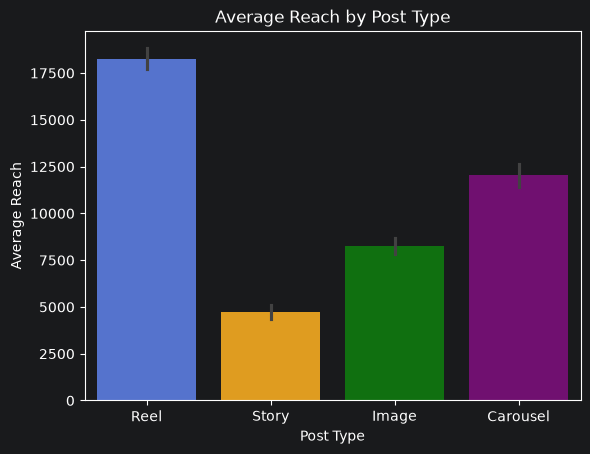

In [40]:
# plt.figure(figsize = (8,5))
sns.barplot(data=df, x="Post_Type", y="Reach",hue="Post_Type",palette=["royalblue", "orange", "green", "purple"])
plt.title("Average Reach by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Average Reach")
plt.show()

#### Likes vs Reach

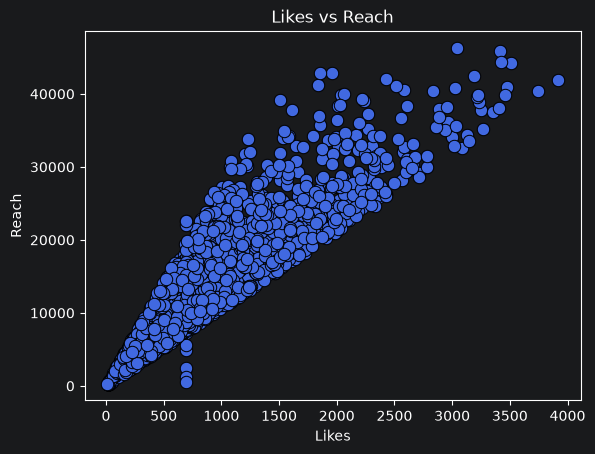

In [41]:
# plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Likes",
    y="Reach",color="royalblue",
    edgecolor="black",
    s=80
)

plt.title("Likes vs Reach")
plt.xlabel("Likes")
plt.ylabel("Reach")

plt.show()

#### Comments vs Reach

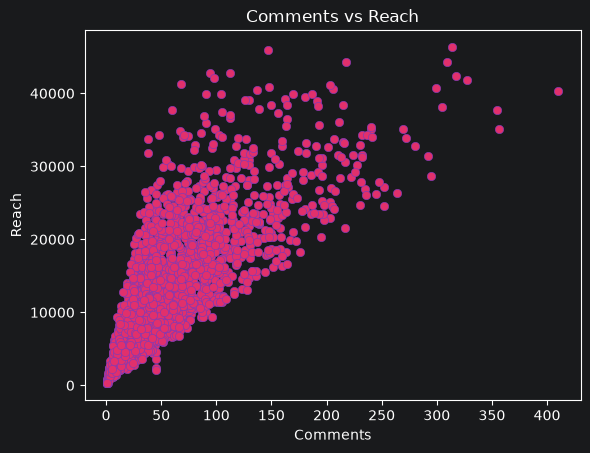

In [42]:
sns.scatterplot(data=df,x="Comments",y="Reach",color="#E1306C",
    edgecolor="#833AB4")
plt.title("Comments vs Reach")
plt.show()

#### Shares vs Reach

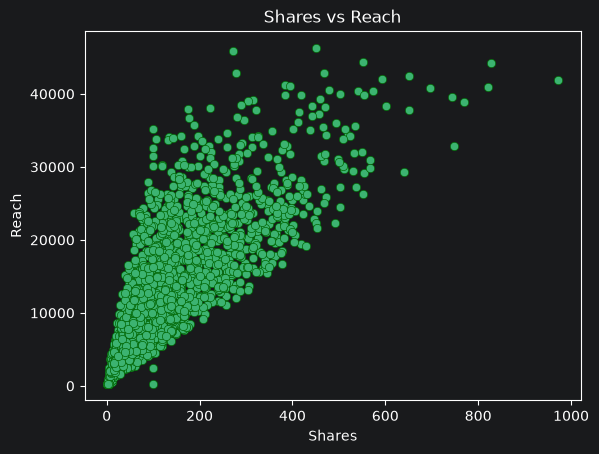

In [43]:
sns.scatterplot(data=df,x="Shares",y="Reach",color="mediumseagreen",
    edgecolor="darkgreen")
plt.title("Shares vs Reach")
plt.show()

#### Saves vs Reach

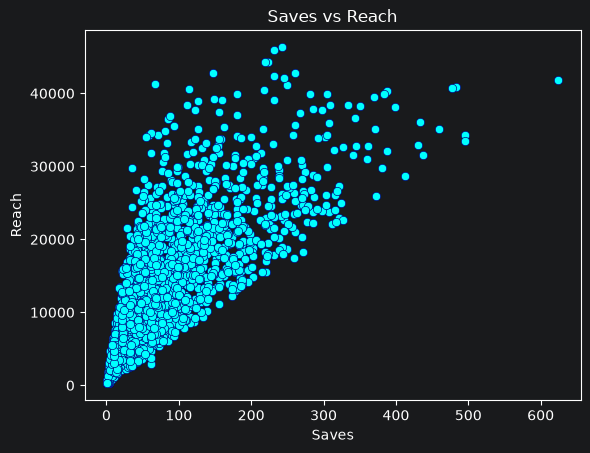

In [44]:
sns.scatterplot(data=df,x="Saves",y="Reach",color="cyan",
    edgecolor="navy")
plt.title("Saves vs Reach")
plt.show()

#### Posting Time Analysis

What posting hour has the highest average reach?

In [45]:
hourly_reach = df.groupby("Posting_Hour")["Reach"].mean()

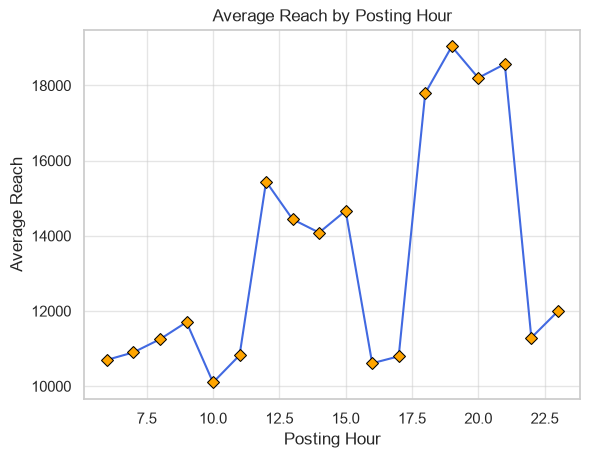

In [46]:
sns.set_theme(style="whitegrid",context="notebook")
sns.lineplot(x=hourly_reach.index, y=hourly_reach.values,
    color="royalblue",
    marker="D",
    markerfacecolor="orange",
    markeredgecolor="black",markersize=6)
plt.title("Average Reach by Posting Hour")
plt.xlabel("Posting Hour")
plt.ylabel("Average Reach")
plt.show()

#### Day Analysis

In [47]:
day_reach = df.groupby("Day")["Reach"].mean()

day_reach.sort_values(ascending=False)

Day
Saturday     14353.888112
Sunday       13857.269231
Tuesday      13747.555944
Monday       13273.143357
Thursday     13108.912281
Wednesday    12927.045455
Friday       12868.982456
Name: Reach, dtype: float64

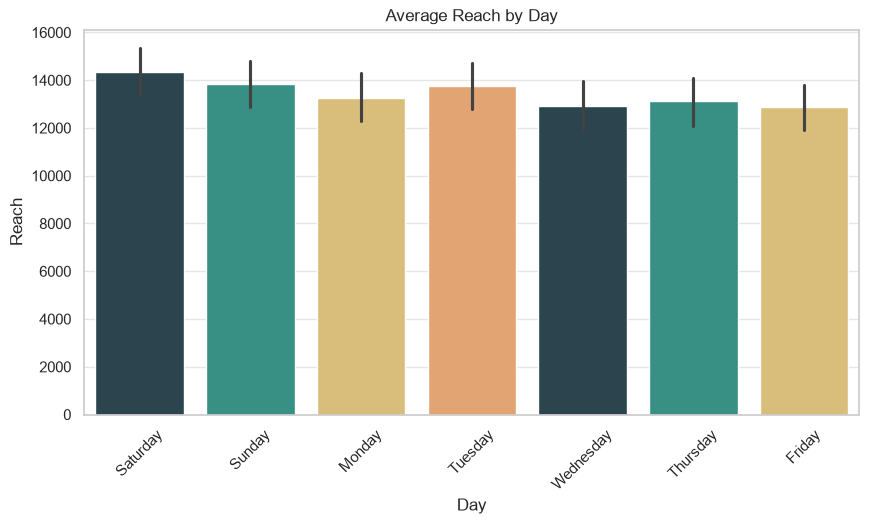

In [48]:
plt.figure(figsize=(10,5))
sns.set_theme(style="whitegrid",context="notebook")
sns.barplot(
    data=df,
    x="Day",
    y="Reach",
    hue="Day",
    palette=["#264653", "#2A9D8F", "#E9C46A", "#F4A261","#264653", "#2A9D8F", "#E9C46A"]
)

plt.xticks(rotation=45)

plt.title("Average Reach by Day")

plt.show()

#### Hashtags Analysis

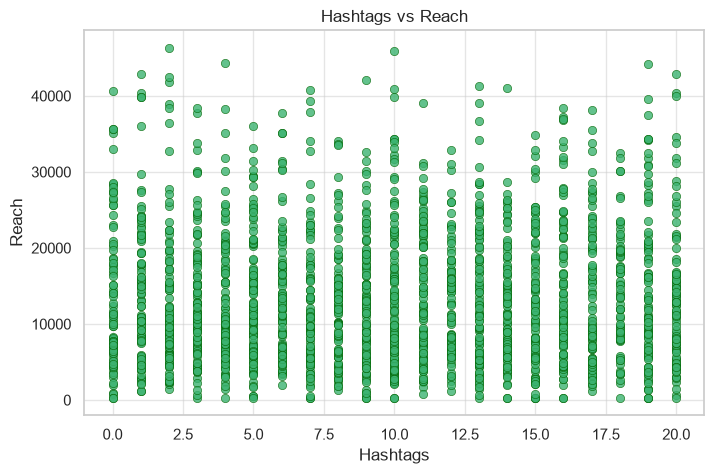

In [49]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Hashtags",
    y="Reach",
    color="mediumseagreen",
    edgecolor="darkgreen",
    alpha=0.8
)

plt.title("Hashtags vs Reach")

plt.show()

#### Correlation Heatmap

In [50]:
numeric_columns = [
    "Caption_Length",
    "Hashtags",
    "Posting_Hour",
    "Likes",
    "Comments",
    "Shares",
    "Saves",
    "Followers",
    "Reach",
    "Impressions",
    "Profile_Visits",
    "Website_Clicks",
    "New_Followers",
    "Total_Engagement",
    "Engagement_Rate"
]

##### Calculate correlation

In [51]:
corr = df[numeric_columns].corr()

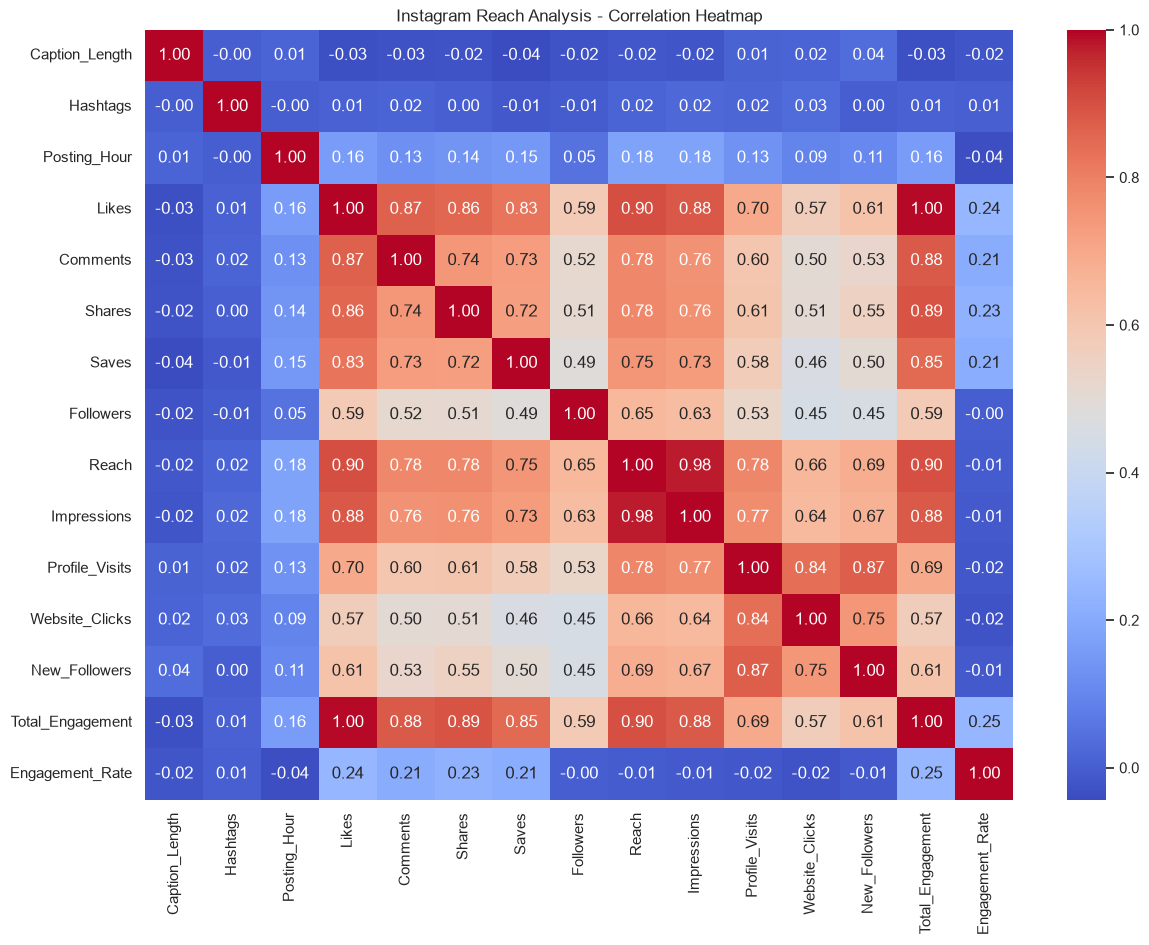

In [52]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt=".2f",
    cmap="coolwarm")
plt.title("Instagram Reach Analysis - Correlation Heatmap")
plt.show()

#### Reach Distribution by Post Type

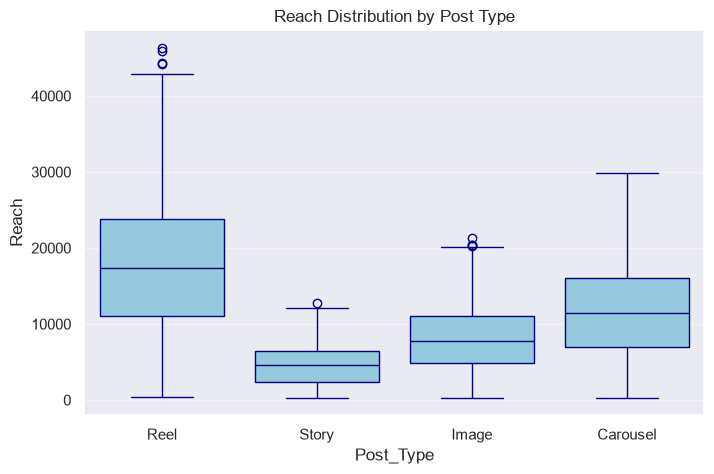

In [63]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Post_Type",
    y="Reach",color="skyblue",
    linecolor="navy",
)

plt.title("Reach Distribution by Post Type")

plt.show()

#### Reach Distribution

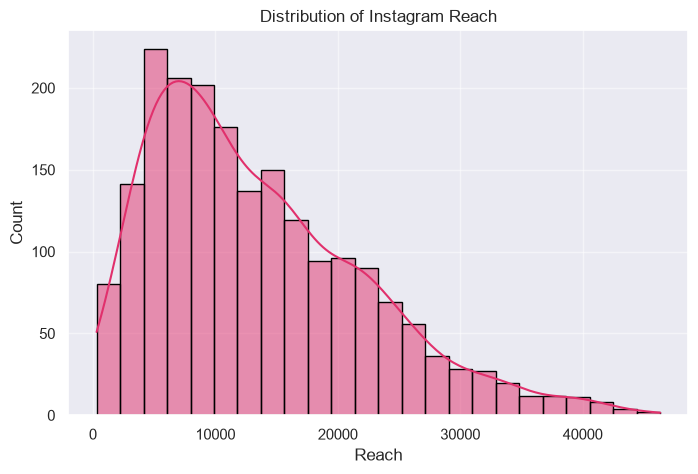

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Reach",
    kde=True,color="#E1306C",
    edgecolor="black")

plt.title("Distribution of Instagram Reach")

plt.show()

#### Top 10 Instagram Posts by Reach

In [55]:
top_10 = df.nlargest(10, "Reach")

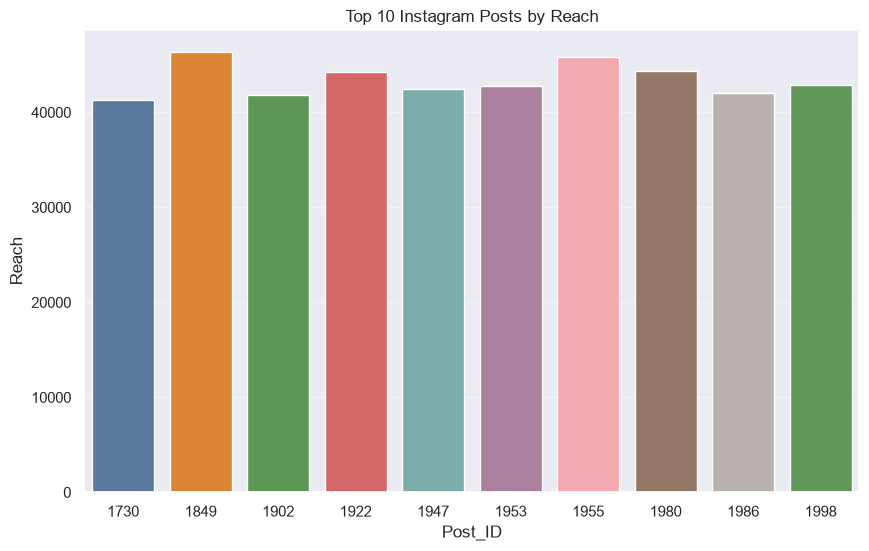

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_10,
    x="Post_ID",
    y="Reach",
    hue="Post_ID",
    palette=[
        "#4C78A8",
        "#F58518",
        "#54A24B",
        "#E45756",
        "#72B7B2",
        "#B279A2",
        "#FF9DA6",
        "#9D755D",
        "#BAB0AC",
        "#59A14F"
    ],
    legend=False
)

plt.title("Top 10 Instagram Posts by Reach")

plt.show()

#### Analyze Engagement by Post Type

In [57]:
df.groupby("Post_Type")[
    "Engagement_Rate"
].mean().sort_values(ascending=False)

Post_Type
Image       8.926371
Reel        8.542203
Story       8.507835
Carousel    8.489425
Name: Engagement_Rate, dtype: float64

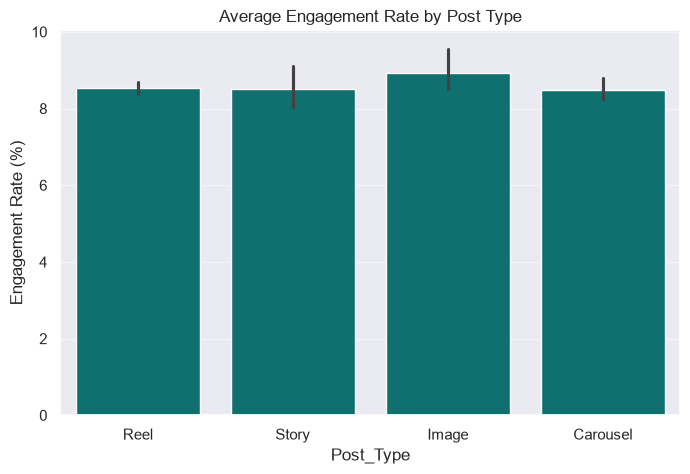

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Post_Type",
    y="Engagement_Rate",
    color="teal"
)

plt.title("Average Engagement Rate by Post Type")
plt.ylabel("Engagement Rate (%)")

plt.show()

## Business Insights

1. Reels demonstrated strong potential for maximizing Instagram reach
   compared with other content formats.

2. Posting time has an important relationship with content performance,
   with evening hours showing stronger average reach in the analysis.

3. Higher engagement is associated with stronger reach, highlighting
   the importance of likes, comments, shares, and saves.

4. Shares and saves are valuable indicators of content quality because
   they represent stronger user interaction than passive viewing.

5. Hashtag quantity alone does not guarantee higher reach. A relevant
   hashtag strategy should be used instead of excessive hashtags.

6. High-reach content can be used to increase profile visits and convert
   viewers into new followers through effective calls-to-action.

7. Content performance should be evaluated using multiple KPIs such as
   reach, engagement rate, shares, saves, and follower growth rather
   than relying only on likes.

8. The analysis can help marketers optimize content type, posting time,
   engagement strategy, and follower-growth campaigns.

##### The Instagram strategy should prioritize high-reach content such as Reels, publish content during high-performing time periods, encourage shares and saves, and use strong calls-to-action to convert reach into profile visits and new followers.